**PRCP-1005-Forest Cover Prediction**

**Forest Cover Prediction**

**Table of Contents:-**



1. Problem Statement
2. Import Required Libraries
3. Dataset loading
4. Exploratory Data Analysis
5. Data Pre-Processing
6. Train-Test Split
7. feature Scaling  
8. Model Building
9. Model Training & Evaluation
10. Model Comparison Report
11. Classification Report
12. Challenges Faced
13. Techniques Used

**Project Overview:**

This project focuses on predicting forest cover types in the Roosevelt National Forest of Northern Colorado using cartographic variables such as elevation, slope, soil type, and wilderness area. The dataset, sourced from the US Forest Service and US Geological Survey, covers four wilderness areas with minimal human disturbance, making the cover types a result of natural ecological processes. This is a multiclass classification problem with seven target classes (Cover_Type 1–7), where the goal is to build the most accurate predictive model using machine learning techniques.

**Problem Statement**
1. Prepare a complete data analysis report on the given data.

2. Create a predictive model which helps  to predict seven different cover types in four different wilderness areas of the Forest with the best accuracy.

3. Create a report stating the performance of multiple models on this data and suggest the best model for production.

4. Create a report which should include challenges you faced on data and what technique used with proper reason.


**Dataset Desciption**

The dataset contains 15,120 observations and 54 features describing cartographic and ecological characteristics of 30×30 meter forest cells — including elevation, slope, distance to hydrology/roadways/fire points, hillshade indices, and one-hot encoded wilderness area and soil type indicators.

**Type:** Multiclass Classification (7 cover types)

**Total columns:** 54 (10 continuous + 4 wilderness binary + 40 soil type binary)

**Total rows:** 15,120

**Key challenge:** Heavily imbalanced classes in the full population (though this training subset is typically balanced — worth confirming with value_counts()), many binary features, moderate dimensionality


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

**Dataset Loading**

In [2]:
df = pd.read_csv("/content/train.csv")

**Exploratory Data Analysis**

In [3]:
df.head()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5


In [4]:
df.describe()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,15120.00000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,...,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000
mean,7560.50000,2749.322553,156.676653,16.501587,227.195701,51.076521,1714.023214,212.704299,218.965608,135.091997,...,0.045635,0.040741,0.001455,0.006746,0.000661,0.002249,0.048148,0.043452,0.030357,4.000000
std,4364.91237,417.678187,110.085801,8.453927,210.075296,61.239406,1325.066358,30.561287,22.801966,45.895189,...,0.208699,0.197696,0.038118,0.081859,0.025710,0.047368,0.214086,0.203880,0.171574,2.000066
min,1.00000,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3780.75000,2376.000000,65.000000,10.000000,67.000000,5.000000,764.000000,196.000000,207.000000,106.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,7560.50000,2752.000000,126.000000,15.000000,180.000000,32.000000,1316.000000,220.000000,223.000000,138.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,11340.25000,3104.000000,261.000000,22.000000,330.000000,79.000000,2270.000000,235.000000,235.000000,167.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,15120.00000,3849.000000,360.000000,52.000000,1343.000000,554.000000,6890.000000,254.000000,254.000000,248.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


*Vertical_Distance_To_Hydrology *has a negative minimum (-146). It means the cell is below the elevation of the nearest water feature

*Hillshade_9am and Hillshade_3pm *have a minimum of 0 — hillshade is a 0–255 index, so 0 is technically valid (deep shadow).

*Aspect ranges* 0–360 (compass degrees) —  this is a circular feature.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Id                                  15120 non-null  int64
 1   Elevation                           15120 non-null  int64
 2   Aspect                              15120 non-null  int64
 3   Slope                               15120 non-null  int64
 4   Horizontal_Distance_To_Hydrology    15120 non-null  int64
 5   Vertical_Distance_To_Hydrology      15120 non-null  int64
 6   Horizontal_Distance_To_Roadways     15120 non-null  int64
 7   Hillshade_9am                       15120 non-null  int64
 8   Hillshade_Noon                      15120 non-null  int64
 9   Hillshade_3pm                       15120 non-null  int64
 10  Horizontal_Distance_To_Fire_Points  15120 non-null  int64
 11  Wilderness_Area1                    15120 non-null  int64
 12  Wild

In [6]:
df.shape

(15120, 56)

The dataset contains no missing values across all 56 columns, and all features are numeric, including the one-hot encoded wilderness and soil type indicators. No type conversion is required before modeling.

*Distribution Check*

Cover_Type
1    2160
2    2160
3    2160
4    2160
5    2160
6    2160
7    2160
Name: count, dtype: int64


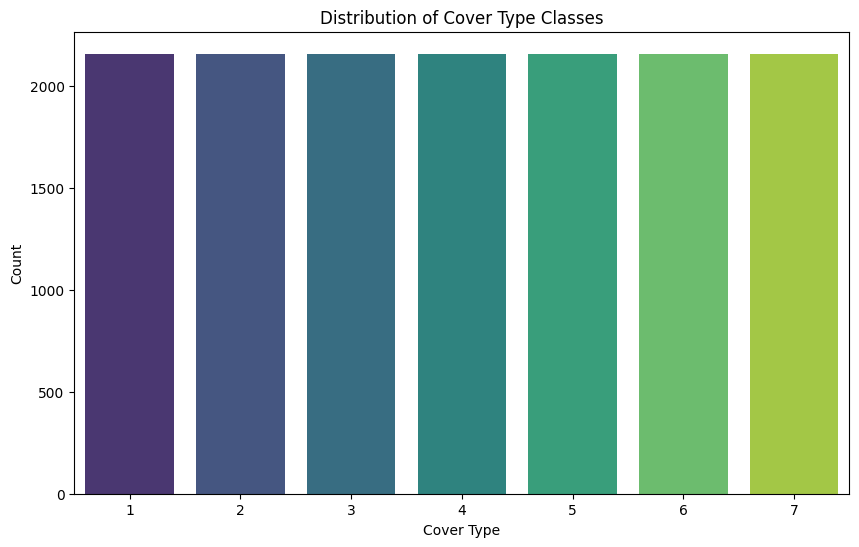

In [7]:
print(df['Cover_Type'].value_counts().sort_index())

plt.figure(figsize=(10,6))
sns.countplot(x ='Cover_Type', data = df, palette = 'viridis')
plt.title('Distribution of Cover Type Classes')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

 This 15,120-row training subset is perfectly balanced with exactly 2,160 observations per class. This is a deliberate stratified sampling choice by the dataset provider to prevent majority-class bias during model training. As a result, class imbalance handling techniques (e.g., SMOTE, class weighting) are not required for this subset, though accuracy alone remains a reasonable evaluation metric here — unlike on the full population, where per-class metrics would be essential. This should still be noted as a limitation: a model trained on this balanced subset may not generalize equally well to the true, imbalanced class distribution found in the wild.

*Univariate analysis of continuous features*

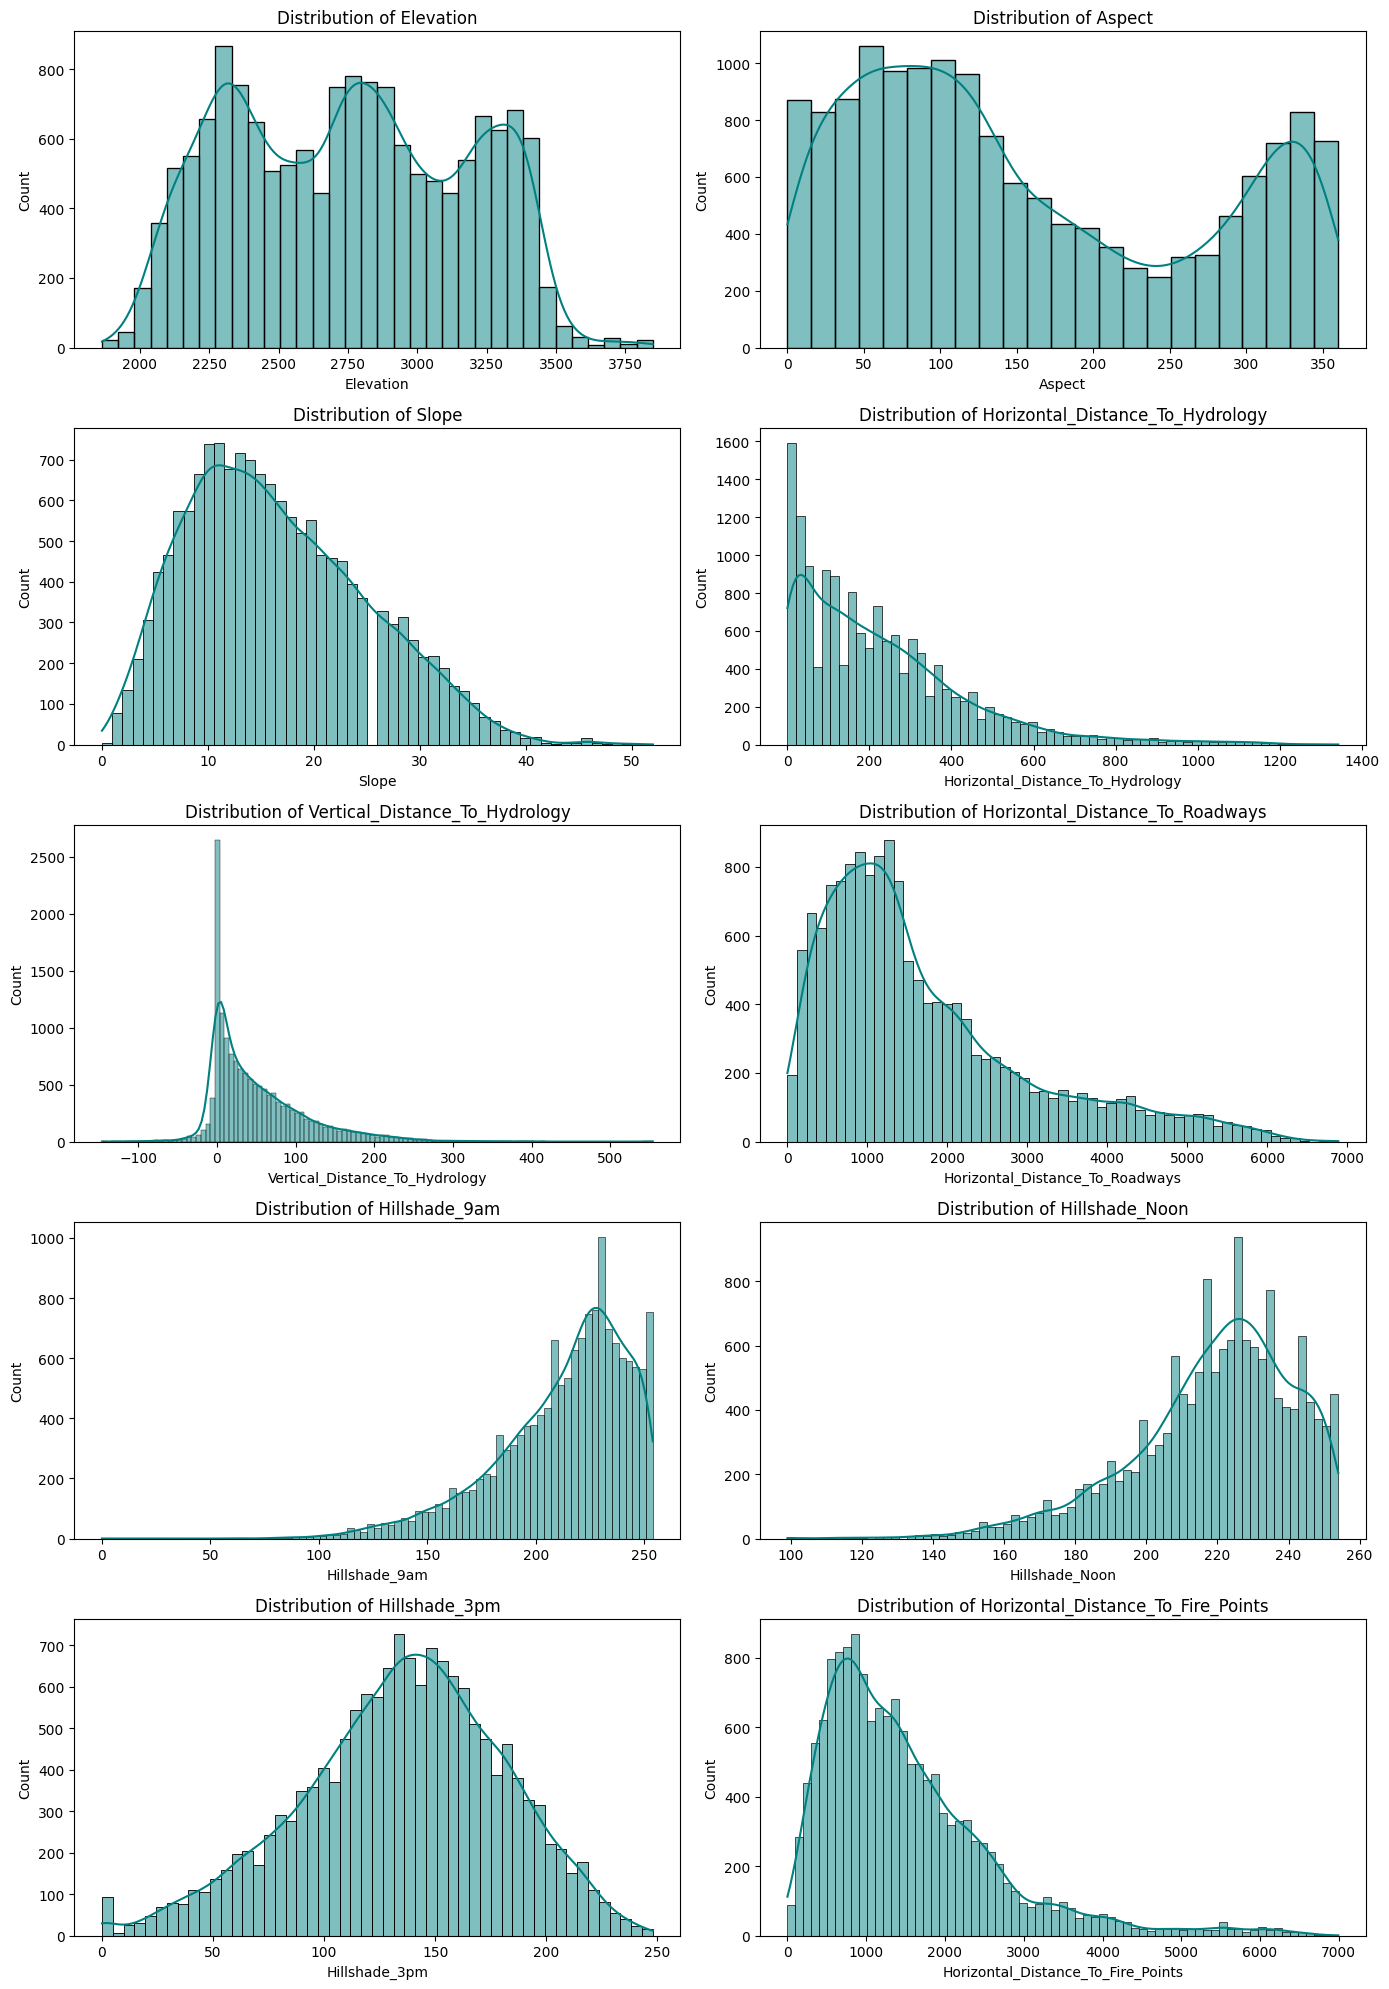

In [8]:
continuous_cols =['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()
for i , col in enumerate(continuous_cols):
  sns.histplot(data = df, x = col, kde = True, ax = axes[i], color='teal')
  axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

*Distribution Insights:*

**Elevation-** The graph has more than one peak, meaning the data has different elevation groups. This shows elevation could be a strong feature to predict cover type, since different forest types may grow at different heights.

**Aspect-** This graph has two humps, one near 0-100° and another near 300-360°, with very few values in the middle (200-250°). This makes sense because Aspect is measured in degrees (0°-360°), and 360° is actually very close to 0° (like a compass direction). So this is a "circular" type of feature.

**Slope-** Most values are small (between 5-25°), and only a few areas have a very steep slope. The graph is right-skewed, meaning it has a long tail on the right side.

**Horizontal_Distance_To_Hydrology-** Most forest cells are very close to water bodies (small distance), and only a few are far away. So this graph is also right-skewed.

**Vertical_Distance_To_Hydrology-** Most values are near 0, meaning the land is almost at the same height as nearby water. A few values are negative, meaning that spot is a little lower than the water level nearby — this is normal, not an error.

**Horizontal_Distance_To_Roadways-** Most areas are close to roads, but some are very far, so the graph has a long right tail.

**Hillshade_9am-** Most values are high (close to 255), meaning in the morning most areas get good sunlight. Very few areas are dark.

**Hillshade_Noon-** Same pattern, but even more values are concentrated in a high range (200-250), showing that at noon, sunlight is more even everywhere.

**Hillshade_3pm-** This one looks more balanced/normal shaped compared to 9am and noon, meaning by 3pm the light amount becomes more evenly spread across different areas.

**Horizontal_Distance_To_Fire_Points-** Most areas are within 3000m of a fire ignition point, and very few are farther, so this is right-skewed too.

**Summary:**

Most of the distance-based columns (like distance to water, roads, and fire points) and Slope are right-skewed, meaning they have many small values and a few very large ones. The Hillshade columns show different shapes depending on the time of day. Elevation looks like it has multiple groups, which might help the model separate cover types. Since many columns are skewed, we may need to scale the data before training the model.

*Finding Outliers*

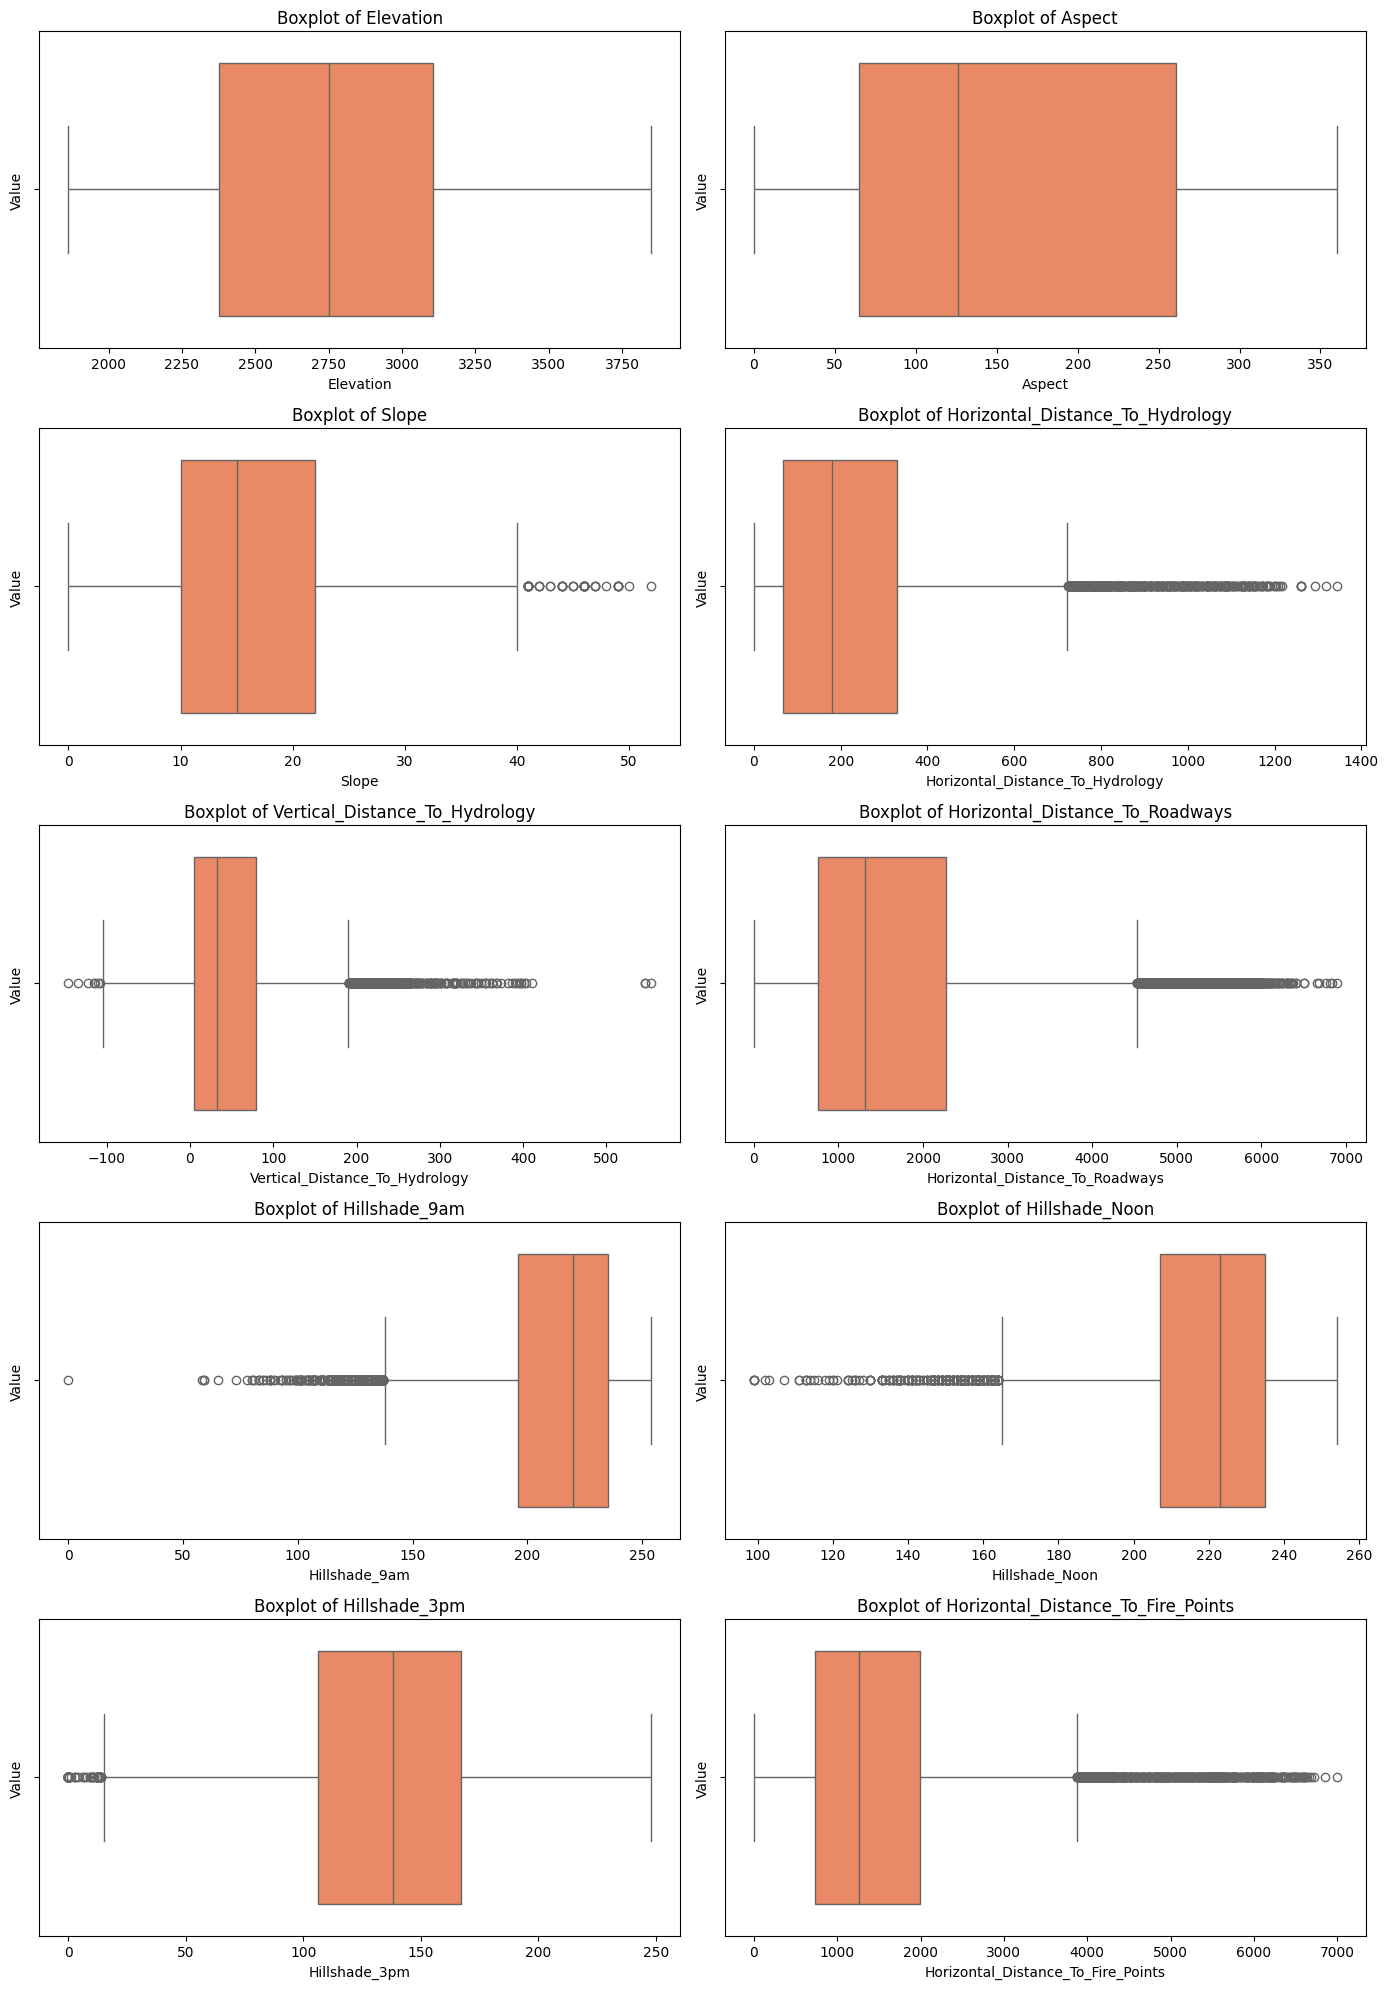

In [9]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14,20))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
  sns.boxplot(data = df, x = col, ax = axes[i], color = 'coral')
  axes[i].set_title(f'Boxplot of {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

*Boxplot Insights*

**Elevation-** No outliers. Data is spread nicely without extreme values.
**Aspect-** No outliers, but the box is not equally divided in the middle, which means most of the data is spread towards the higher (right) side.

**Slope-** A few outliers on the right side (some unusually steep areas).

**Horizontal_Distance_To_Hydrology-** Many outliers on the right side (a few forest cells are located very far from water).

**Vertical_Distance_To_Hydrology-** Has outliers on both sides, but more outliers on the right side.

**Horizontal_Distance_To_Roadways-** Many outliers on the right side (some areas are very far from roads).

**Hillshade_9am-** Most areas get good sunlight in the morning, but a few outliers on the left show areas getting very little light.

**Hillshade_Noon-** Most areas get good sunlight at noon, but there are still a few outliers with low light.

**Hillshade_3pm-** This is the most balanced graph in terms of sunlight, but a few outliers still exist.

**Horizontal_Distance_To_Fire_Point-** Many outliers on the right side (some areas are very far from fire points).

**Summary:** Overall, many columns (especially the distance-based ones) have a good number of outliers on the right side. Since this project requires building and comparing multiple models (not just one), and different models react differently to outliers — tree-based models like Random Forest and Gradient Boosting are generally not very sensitive to outliers, while distance-based models like KNN and Logistic Regression can be affected by them — we will keep the outliers for now and evaluate their impact during model comparison. If needed, we can apply outlier treatment (like capping) separately for the outlier-sensitive models later in the Data Pre-Processing section.


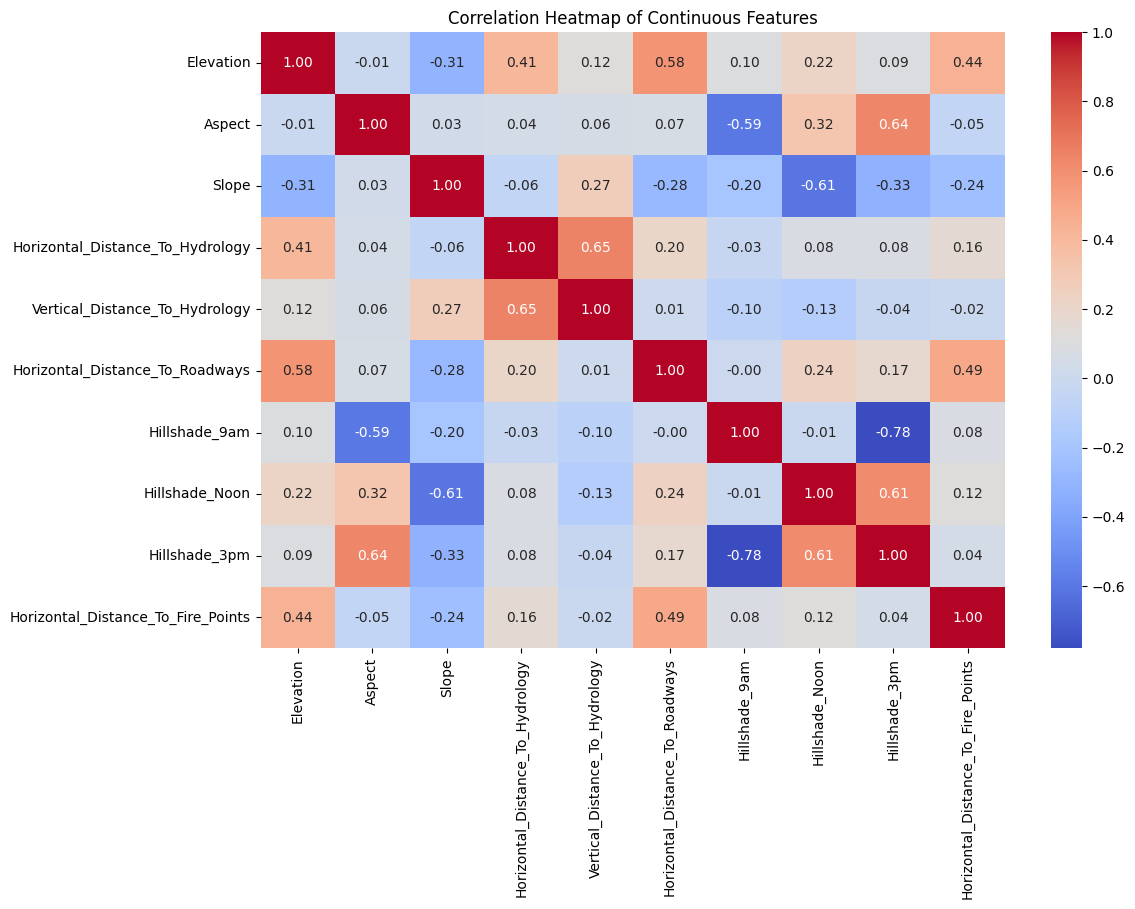

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df[continuous_cols].corr(), annot = True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap of Continuous Features')
plt.show()

 The heatmap shows both positive and negative correlations. The strongest relationship overall is between Hillshade_9am and Hillshade_3pm (-0.78) — a negative correlation, meaning when morning sunlight is high, afternoon sunlight tends to be low, which makes sense since they represent opposite times of day. Aspect also shows strong negative correlations with Hillshade_9am (-0.59) and positive correlation with Hillshade_3pm (0.64), meaning the direction a slope faces has a big effect on what time of day it receives sunlight. None of the correlations are close to 1.0 or -1.0, so there is no serious multicollinearity problem — meaning we don't need to drop any continuous feature before modeling.



*Cover_Type-Wise Comparision*

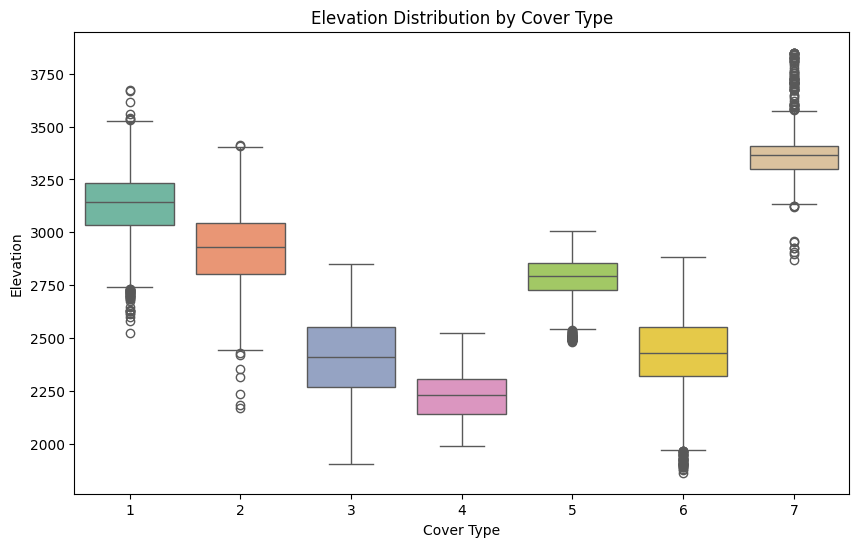

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = 'Cover_Type', y = 'Elevation', palette = 'Set2')
plt.title('Elevation Distribution by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Elevation')
plt.show()

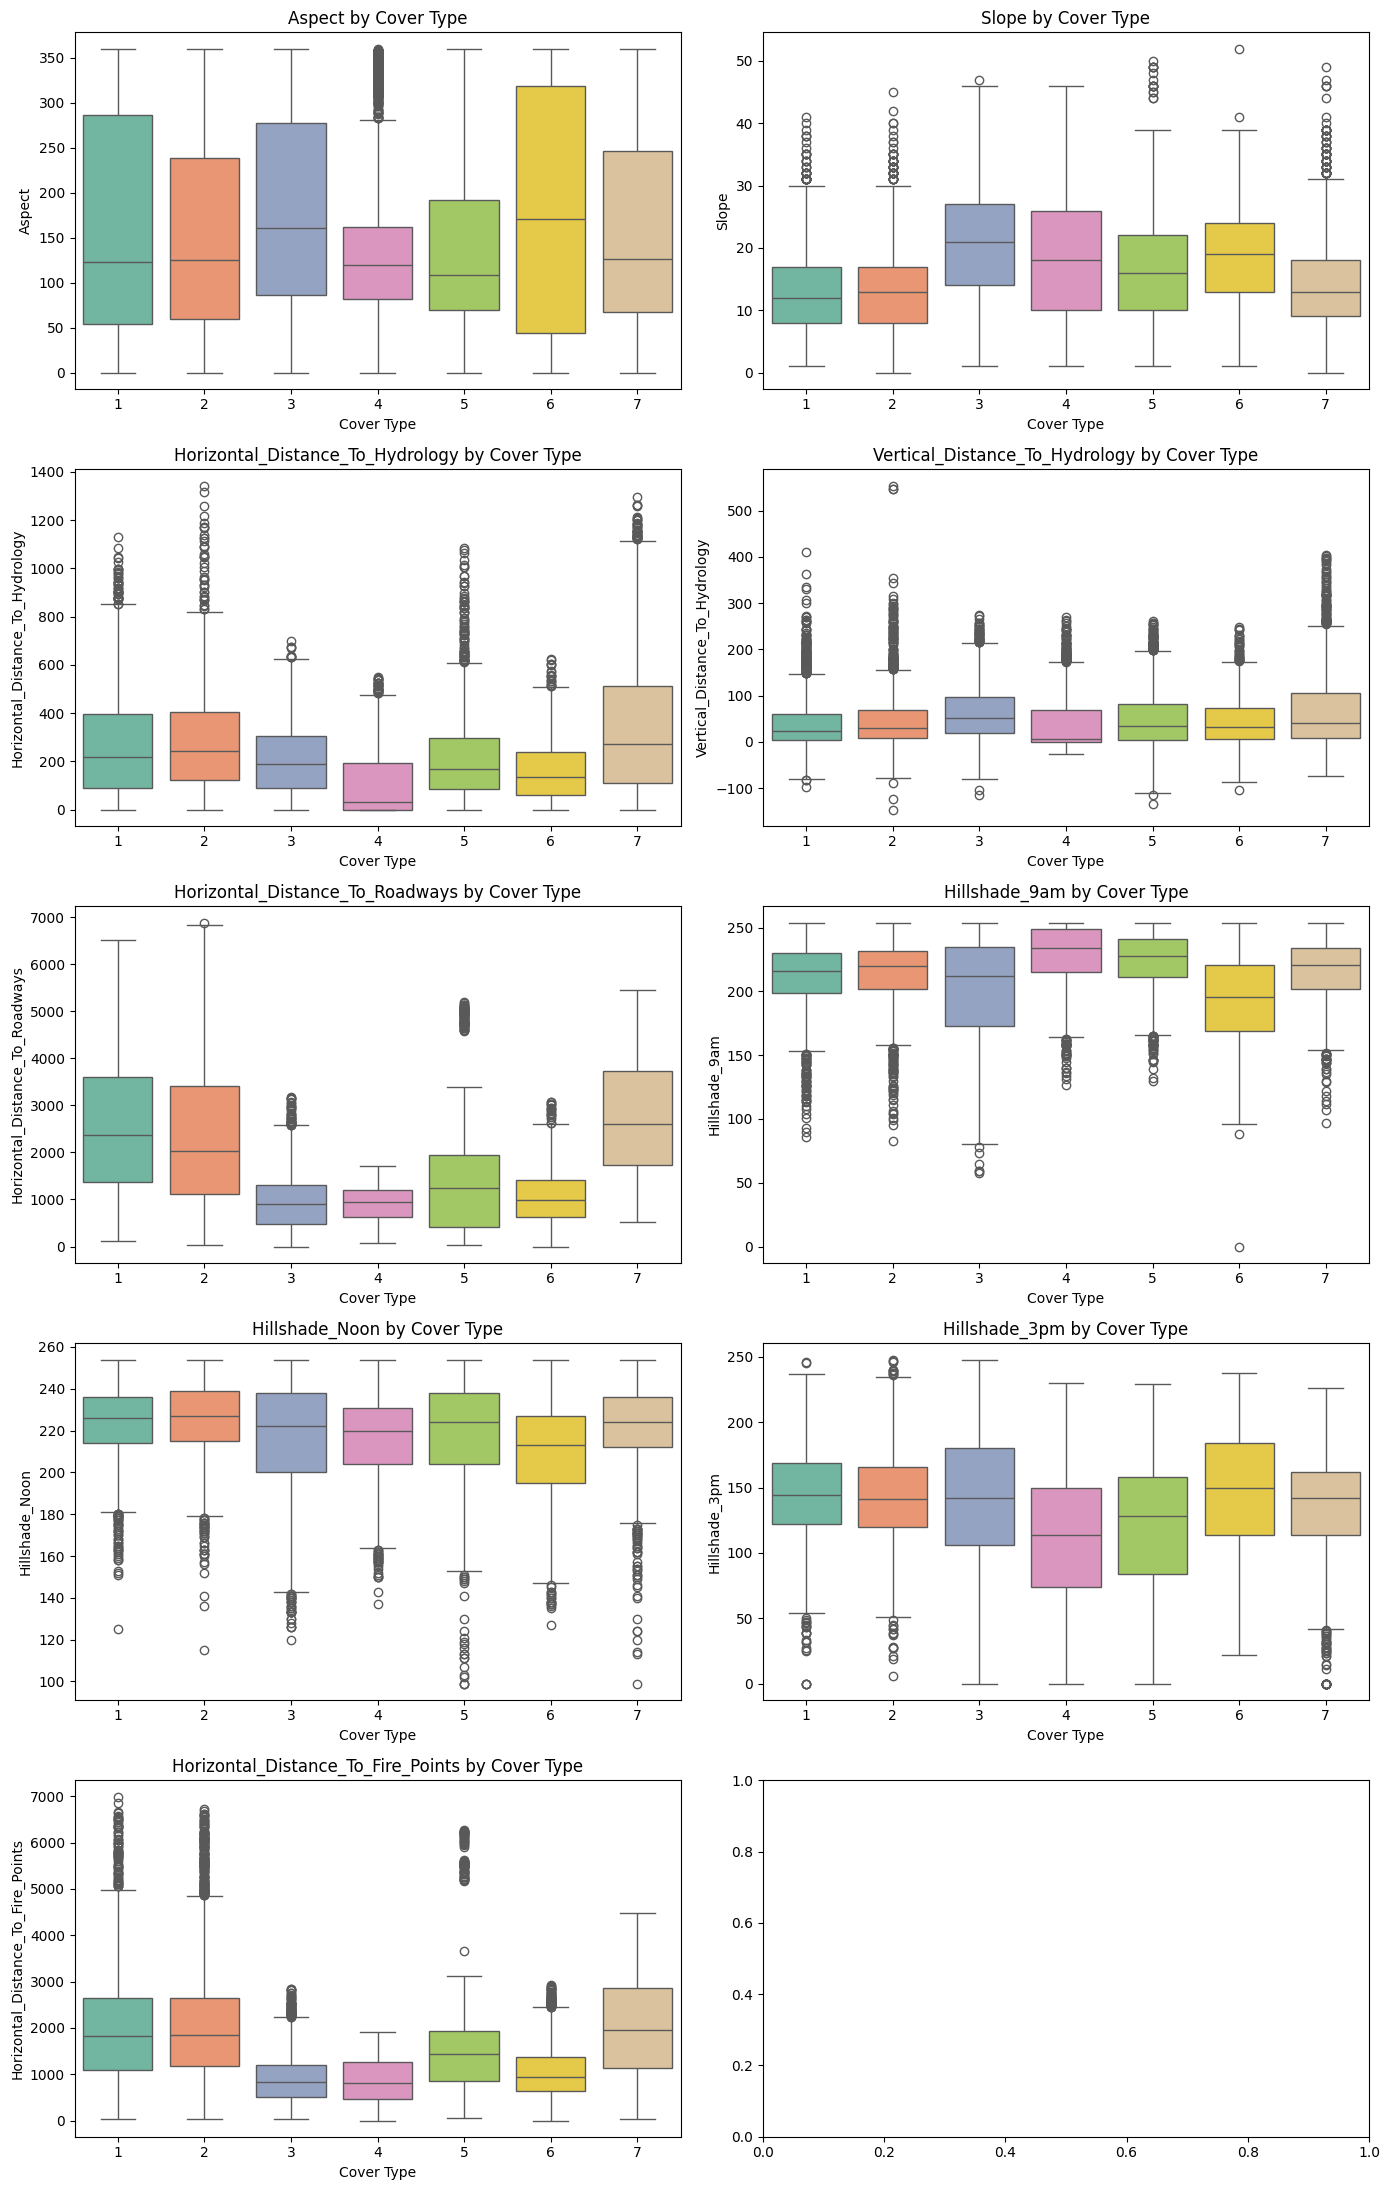

In [12]:
remaining_cols = ['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points']

Fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 22))
axes = axes.flatten()
for i , col in enumerate(remaining_cols):
  sns.boxplot(data = df, x = 'Cover_Type', y = col, ax = axes[i], palette = 'Set2')
  axes[i].set_title(f'{col} by Cover Type')
  axes[i].set_xlabel('Cover Type')
  axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [13]:
df.groupby('Cover_Type')['Slope'].describe()

,count,mean,std,min,25%,50%,75%,max
Cover_Type,,,,,,,,
1,2160.0,13.112963,6.817153,1.0,8.0,12.0,17.0,41.0
2,2160.0,13.423611,7.038483,0.0,8.0,13.0,17.0,45.0
3,2160.0,20.628704,8.888591,1.0,14.0,21.0,27.0,47.0
4,2160.0,18.468519,9.361156,1.0,10.0,18.0,26.0,46.0
5,2160.0,16.724537,8.440048,1.0,10.0,16.0,22.0,50.0
6,2160.0,18.986111,7.714618,1.0,13.0,19.0,24.0,52.0
7,2160.0,14.166667,7.315810,0.0,9.0,13.0,18.0,49.0


In [14]:
df.groupby('Cover_Type')[remaining_cols].median()

,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cover_Type,,,,,,,,,
1,123.0,12.0,218.0,23.0,2377.0,216.0,226.0,144.0,1817.5
2,125.0,13.0,242.0,31.0,2023.5,220.0,227.0,141.0,1851.0
3,161.0,21.0,190.0,51.0,897.0,212.0,222.0,142.0,828.0
4,119.0,18.0,30.0,6.0,942.0,234.0,220.0,114.0,808.0
5,108.0,16.0,170.0,35.0,1253.5,228.0,224.0,128.0,1432.0
6,171.0,19.0,134.0,33.0,993.0,196.0,213.0,150.0,942.0
7,126.0,13.0,270.0,42.0,2611.5,221.0,224.0,142.0,1963.0


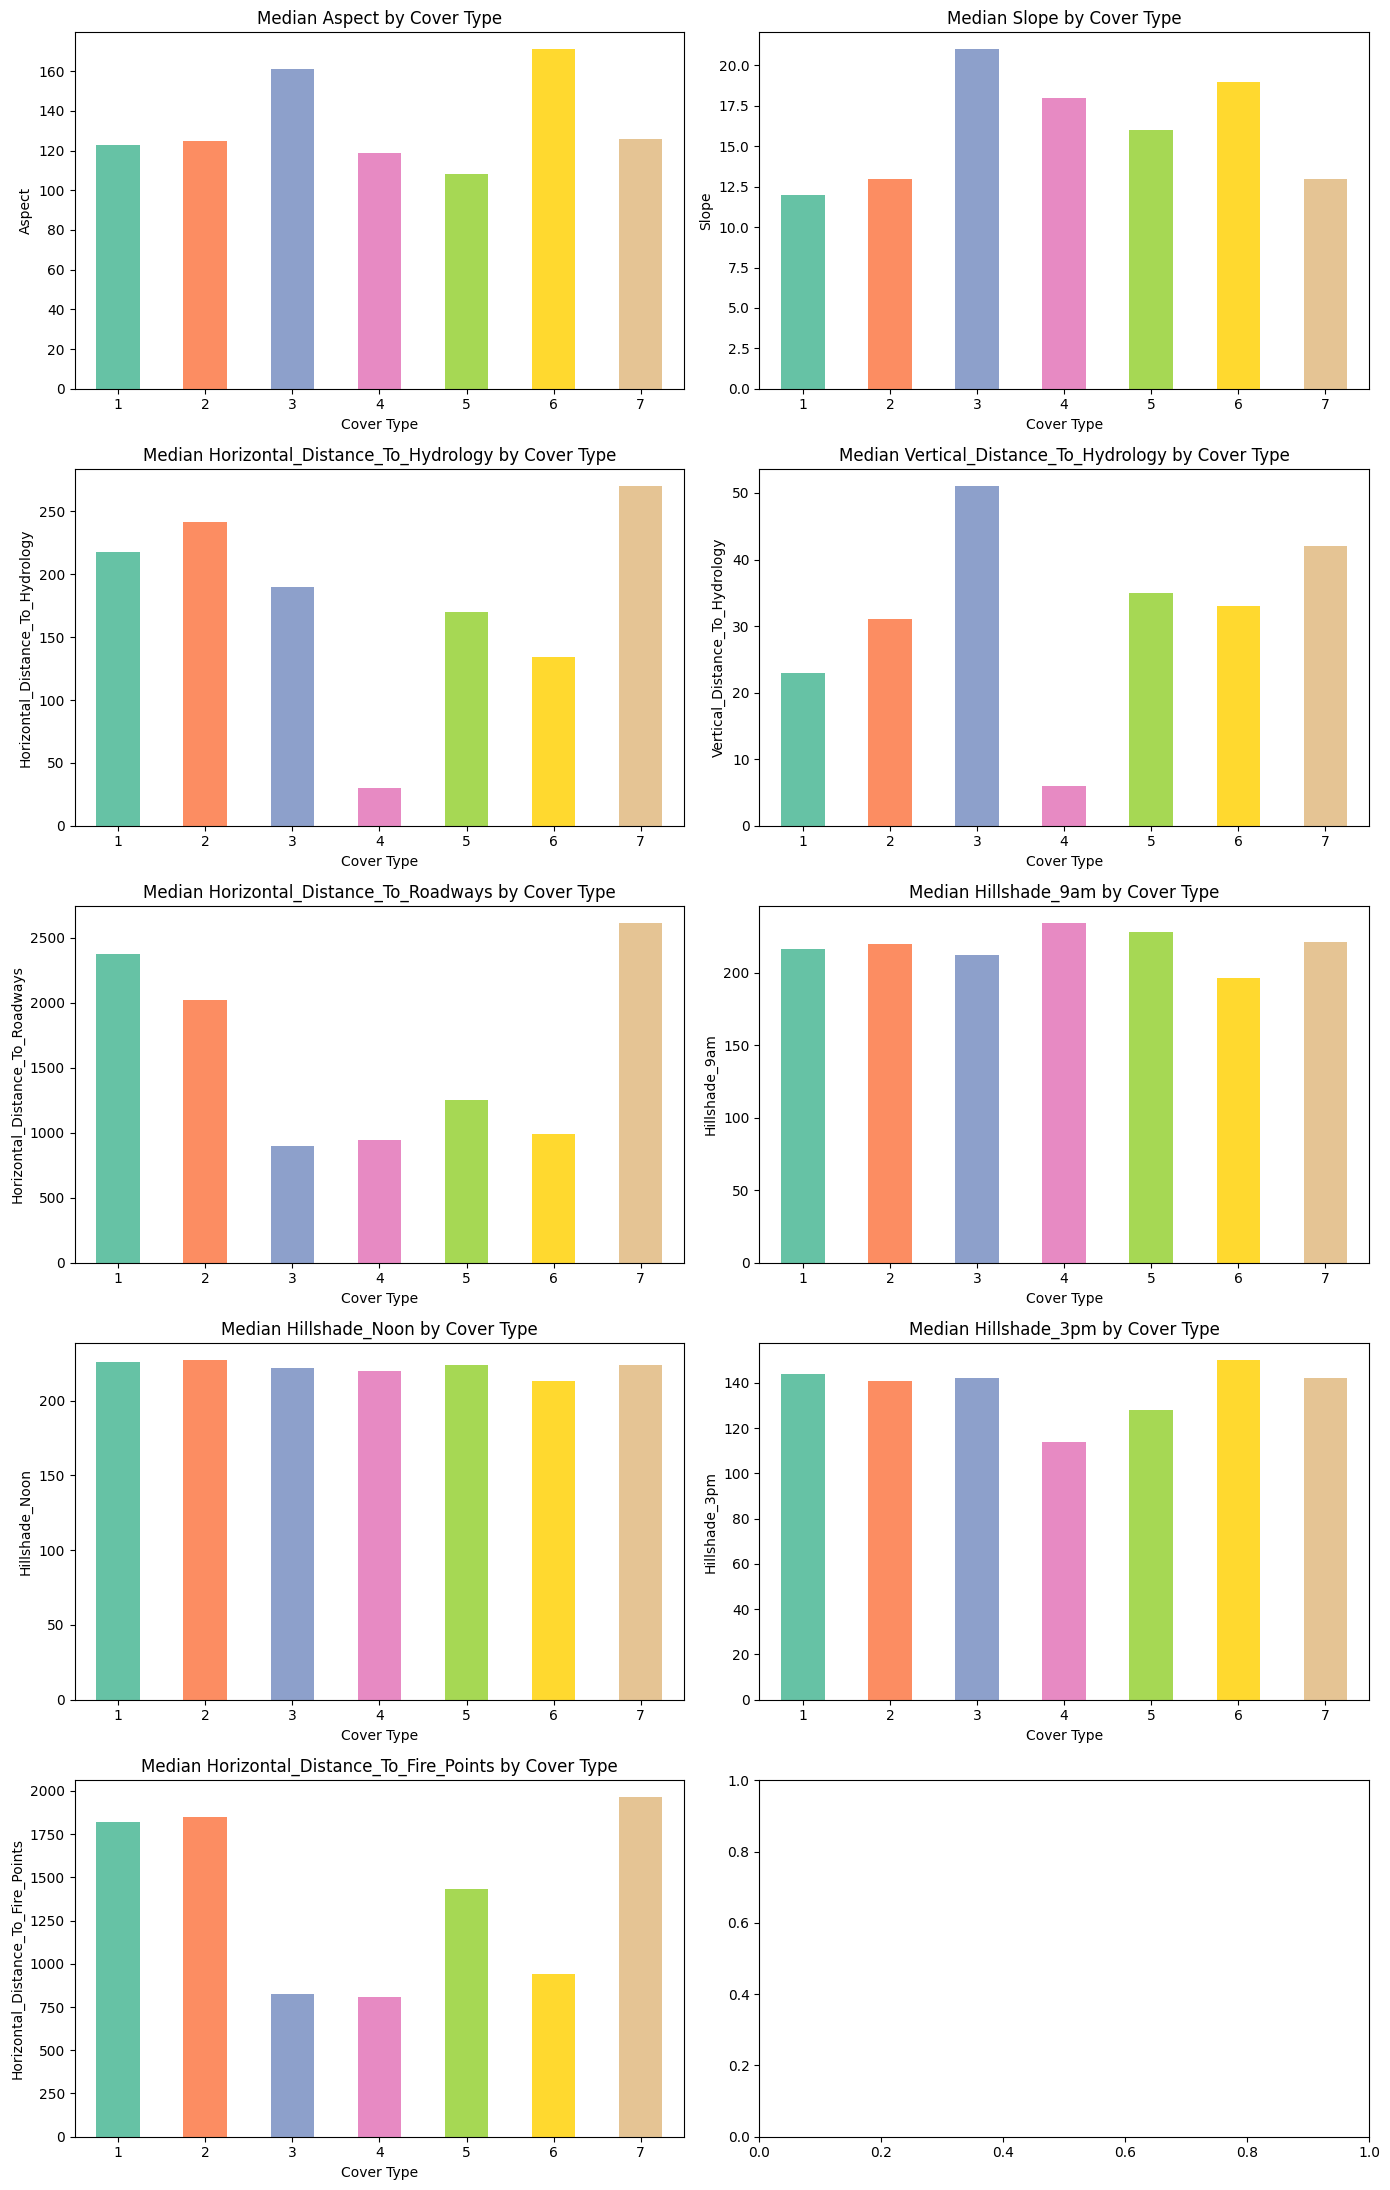

In [15]:
median_df = df.groupby('Cover_Type')[remaining_cols].median()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 22))
axes = axes.flatten()
for i, col in enumerate(remaining_cols):
  median_df[col].plot(kind='bar', ax= axes[i], color = sns.color_palette('Set2', 7))
  axes[i].set_title(f'Median {col} by Cover Type')
  axes[i].set_xlabel('Cover Type')
  axes[i].set_ylabel(col)
  axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Hillshade_Noon shows almost identical median values across most Cover Types (220-227), except Cover Type 6, which is slightly lower (213). This narrow spread suggests Hillshade_Noon does not vary much by cover type and may have relatively low predictive power for distinguishing between classes — unlike features like Elevation or Horizontal_Distance_To_Roadways, which show much wider separation across cover types. We will let feature importance techniques (like from Random Forest) confirm this later during model building rather than dropping it manually at this stage.

**Data Pre-Processing**

## Data Pre-Processing Checklist

| Step | Decision | Reason |
|------|----------|--------|
| Missing values | None found | Confirmed earlier — no action needed |
| Duplicates | None found | Confirmed earlier — no action needed |
| Id column | Drop it | It's just a row identifier, not a predictive feature — including it would confuse the model |
| Outliers | Keep for now | Decided earlier — will evaluate per-model during comparison (tree models are robust, distance-based models may need treatment later) |
| Class imbalance | No action needed | Confirmed perfectly balanced (2160 per class) |
| Multicollinearity | No action needed | Confirmed no correlation above ±0.78, nothing dangerously high |
| Aspect (cyclical) | Optional — flag it | Could apply sin/cos transformation; note as a possible improvement even if not applied |
| Wilderness/Soil columns | Already binary | No encoding needed — already 0/1 |

In [16]:
df= df.drop('Id', axis = 1)
print("Shape after dropping Id:", df.shape)

Shape after dropping Id: (15120, 55)


In [17]:
x = df.drop('Cover_Type', axis = 1)
y = df['Cover_Type']

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (15120, 54)
Shape of y: (15120,)


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42, stratify = y )

print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

# stratify=y here — since your classes are perfectly balanced, this ensures that balance is preserved
#  in both the train and test sets too.

Shape of x_train: (10584, 54)
Shape of y_train: (10584,)
Shape of x_test: (4536, 54)
Shape of y_test: (4536,)


In [19]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Shape of x_train_scaled:", x_train_scaled.shape)
print("Shape of x_test_scaled:", x_test_scaled.shape)

Shape of x_train_scaled: (10584, 54)
Shape of x_test_scaled: (4536, 54)


## Summary of Data Pre-Processing

Based on the checklist made after EDA, the following pre-processing steps were carried out:

1. **Id column removed** – The Id column was dropped since it is just a row number and does not help in predicting Cover_Type. This reduced the dataset from 55 columns to 54 feature columns.

2. **Features and target separated** – The data was split into X (54 input features) and y (Cover_Type, the target variable).

3. **No missing values or duplicates** – Confirmed during EDA, so no cleaning was needed here.

4. **Outliers kept as they are** – Outliers found during EDA were not removed. Since multiple models will be compared, and outlier sensitivity differs by model (tree-based models are less affected, while KNN and SVM can be more sensitive), the plan is to observe their effect during model comparison rather than removing them upfront.

5. **No class imbalance handling needed** – The dataset was already perfectly balanced (2160 rows for each of the 7 Cover Types), so techniques like SMOTE were not required.

6. **No multicollinearity treatment needed** – The correlation heatmap showed no feature pair above ±0.8, so no features were dropped for this reason.

7. **Train-Test Split** – The data was split into 70% training and 30% testing using `train_test_split`, with `stratify=y` to make sure each Cover_Type is equally represented in both the training and testing sets.
   - Training set: 10,584 rows
   - Testing set: 4,536 rows

8. **Feature Scaling** – `StandardScaler` was applied to standardize all features to have a mean of ~0 and standard deviation of ~1. The scaler was fit only on the training data (`fit_transform`) and then applied to the test data (`transform`) to avoid data leakage. Scaling was applied to all columns (including binary Wilderness/Soil columns) to keep the pipeline consistent across all models, since some models being compared (KNN, Logistic Regression, SVM) are sensitive to feature scale.

After these steps, the data is fully cleaned, split, and scaled, and is now ready for Model Building.

**Model Building & Evaluation**

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}


In [21]:
results ={}

for name , model in models.items():
  model.fit(x_train_scaled, y_train) #train
  y_pred = model.predict(x_test_scaled) #predict
  acc = accuracy_score(y_test, y_pred)
  results[name] = acc #evaluate

  print(f"\n{name}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
  print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


Logistic Regression
Accuracy: 0.6975
Classification Report:
              precision    recall  f1-score   support

           1       0.65      0.67      0.66       648
           2       0.60      0.51      0.55       648
           3       0.60      0.52      0.56       648
           4       0.80      0.89      0.84       648
           5       0.73      0.76      0.74       648
           6       0.59      0.64      0.61       648
           7       0.88      0.89      0.88       648

    accuracy                           0.70      4536
   macro avg       0.69      0.70      0.69      4536
weighted avg       0.69      0.70      0.69      4536

Confusion Matrix:
[[431 120   1   0  21   0  75]
 [148 333  16   0 113  33   5]
 [  0   5 340  95  29 179   0]
 [  0   0  32 577   0  39   0]
 [ 10  89  19   0 495  35   0]
 [  0   9 155  50  22 412   0]
 [ 71   0   0   0   1   0 576]]

Random Forest
Accuracy: 0.8525
Classification Report:
              precision    recall  f1-score   suppo

## Model Comparison Table

| Rank | Model | Accuracy | Macro F1-Score |
|------|-------|----------|-----------------|
| 1 | Random Forest | 85.25% | 0.85 |
| 2 | Gradient Boosting | 78.88% | 0.78 |
| 3 | KNN | 77.40% | 0.77 |
| 4 | Decision Tree | 76.68% | 0.77 |
| 5 | SVM | 72.09% | 0.72 |
| 6 | Logistic Regression | 69.75% | 0.69 |

**Random Forest performed the best** among all 6 models, with 85.25% accuracy and the most balanced precision/recall across all 7 classes. This makes sense — Random Forest is an ensemble of many decision trees, which handles the mix of continuous and binary features (and the outliers we chose to keep) well, without needing feature scaling to work properly.

**Logistic Regression performed the worst** (69.75%), which is expected since it's a simple linear model, and the relationship between features like Elevation and Cover_Type is not purely linear (as we saw in our boxplots — the classes overlap in complex, non-linear ways).

**A clear pattern across all models:** Cover Types **1, 2, and 6** consistently have the lowest precision/recall, while Cover Types **4 and 7** are predicted the best (often 90%+ F1-score) across every model. Looking at the confusion matrices, **Cover Type 1 and Cover Type 2 are frequently confused with each other** in every single model (e.g., Random Forest confuses 110 samples of Type 2 as Type 1, and 113 of Type 1 as Type 2). This matches what we saw in EDA — Types 1 and 2 have overlapping Elevation ranges (3000–3200m vs 2800–3050m), making them naturally harder to separate.

Similarly, **Cover Types 3 and 6 get confused with each other** across models — again consistent with their overlapping Slope and Elevation ranges found during EDA.

In [22]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10,20,30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid = rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(x_train_scaled, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest CV Accuracy: 0.8525130525862739


In [23]:
gb_params = {
    'n_estimators': [100,200],
    'learning_rate': [ 0.1,0.2],
    'max_depth':[3,5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(x_train_scaled, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Best Gradient Boosting CV Accuracy:", gb_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best Gradient Boosting CV Accuracy: 0.8378683945698384


GridSearchCV improved Gradient Boosting's accuracy meaningfully, from 78.88% to 83.79% (~5 percentage point gain), by increasing max_depth to 5 and using a higher learning_rate of 0.2 with 200 estimators — showing the default parameters were noticeably under-tuned for this dataset. Random Forest, on the other hand, showed no improvement from tuning (staying at 85.25%), confirming its default configuration was already near-optimal. Random Forest remains the best-performing model overall and is the recommended choice for production, though Gradient Boosting is now a much closer second after tuning.

In [24]:
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(x_test_scaled)

print("Random Forest(Tuned) - test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(x_test_scaled)

print("Gradient Boosting(Tuned) - Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Random Forest(Tuned) - test Accuracy: 0.8562610229276896
              precision    recall  f1-score   support

           1       0.79      0.75      0.77       648
           2       0.78      0.68      0.73       648
           3       0.83      0.80      0.81       648
           4       0.92      0.97      0.95       648
           5       0.90      0.95      0.92       648
           6       0.82      0.88      0.85       648
           7       0.93      0.98      0.95       648

    accuracy                           0.86      4536
   macro avg       0.85      0.86      0.85      4536
weighted avg       0.85      0.86      0.85      4536

Gradient Boosting(Tuned) - Test Accuracy: 0.8487654320987654
              precision    recall  f1-score   support

           1       0.77      0.73      0.75       648
           2       0.75      0.67      0.71       648
           3       0.82      0.80      0.81       648
           4       0.94      0.96      0.95       648
           5  

After hyperparameter tuning, Random Forest achieved the highest test accuracy at 85.63%, slightly ahead of Gradient Boosting at 84.88%. Both models show very similar macro F1-scores (0.85), meaning their overall balance across all 7 classes is nearly identical. However, Random Forest edges ahead consistently across most classes, particularly Cover Types 2 and 3, where it shows better recall.
The same pattern we noticed earlier still holds after tuning: Cover Types 1 and 2 remain the hardest to classify (lowest precision/recall in both models), while Cover Types 4 and 7 are predicted almost perfectly (F1-score of 0.95 in both models). This confirms that the difficulty in separating Types 1 and 2 is a genuine, consistent pattern in the data — not something specific to one model or one set of parameters — most likely because their Elevation and other feature ranges overlap significantly, as seen during EDA.
Final recommendation: Random Forest (Tuned) is the best model for production, offering the highest accuracy (85.63%), strong balance across all classes, and being computationally simpler and faster to train/predict than Gradient Boosting, since it builds trees in parallel rather than sequentially.

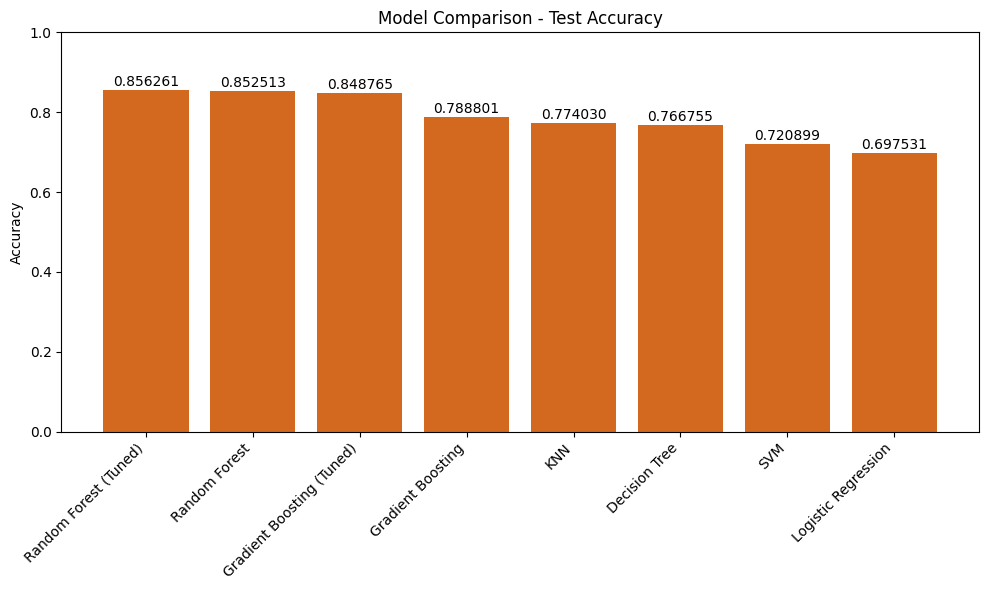

In [27]:
# Update results dictionary with tuned scores.
results['Random Forest (Tuned)'] = accuracy_score(y_test, y_pred_rf)
results['Gradient Boosting (Tuned)'] = accuracy_score(y_test, y_pred_gb)

# Sorted by accuracy
results_sorted = dict(sorted(results.items(), key = lambda x: x[1], reverse = True))

plt.figure(figsize=(10,6))
bars = plt.bar(results_sorted.keys(), results_sorted.values(), color = 'chocolate')
plt.title ('Model Comparison - Test Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:3f}', ha='center')
plt.tight_layout()
plt.show()


**Insight:**
The bar chart clearly shows Random Forest (Tuned) as the best performing model with 85.63% accuracy, closely followed by the untuned Random Forest (85.25%) and Gradient Boosting (Tuned) (84.88%) — these three form a clear top group, well ahead of the remaining models. Gradient Boosting (Tuned) shows the biggest improvement from tuning, jumping from 78.88% (untuned) to 84.88%. KNN, Decision Tree, and SVM form a middle group (72–77%), while Logistic Regression remains the weakest at 69.75%, confirming that this dataset has non-linear patterns that simple linear models cannot capture well.

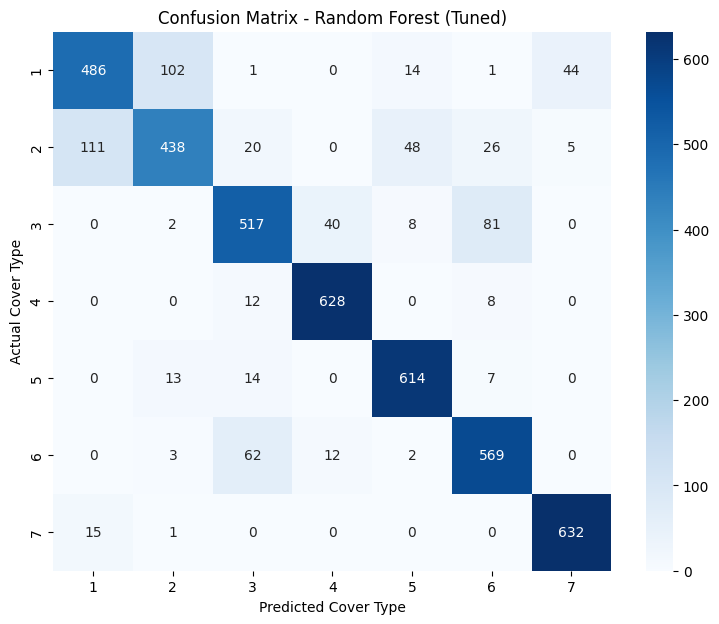

In [28]:
#Confusion Matrix Heatmap

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',
            xticklabels = [1,2,3,4,5,6,7], yticklabels = [1,2,3,4,5,6,7])
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.xlabel('Predicted Cover Type')
plt.ylabel('Actual Cover Type')
plt.show()

**Insight:**
The confusion matrix shows that the model performs very well overall, with most predictions falling correctly along the diagonal (darkest cells). However, some clear confusion patterns exist:

- **Cover Type 1 and 2 are confused most often** — 102 samples of Type 1 were wrongly predicted as Type 2, and 111 samples of Type 2 were wrongly predicted as Type 1. This matches our EDA finding that these two classes have overlapping Elevation ranges.
- **Cover Type 3 and 6 are also frequently confused** — 81 samples of Type 3 were predicted as Type 6, and 62 samples of Type 6 were predicted as Type 3, again consistent with their overlapping Slope and Elevation ranges seen during EDA.
- **Cover Type 1 and 7 show some confusion** — 44 samples of Type 1 were predicted as Type 7, and 15 samples of Type 7 were predicted as Type 1, likely because both types occur at relatively high elevations.
- **Cover Types 4, 5, and 7 have very few misclassifications**, with most of their predictions concentrated correctly on the diagonal — matching their distinct, non-overlapping feature ranges found during EDA (especially Elevation and distance to hydrology).

Overall, the confusion patterns align closely with the overlapping feature ranges identified during EDA, confirming that the model's mistakes are not random but driven by genuine similarity between certain cover types in the real world.

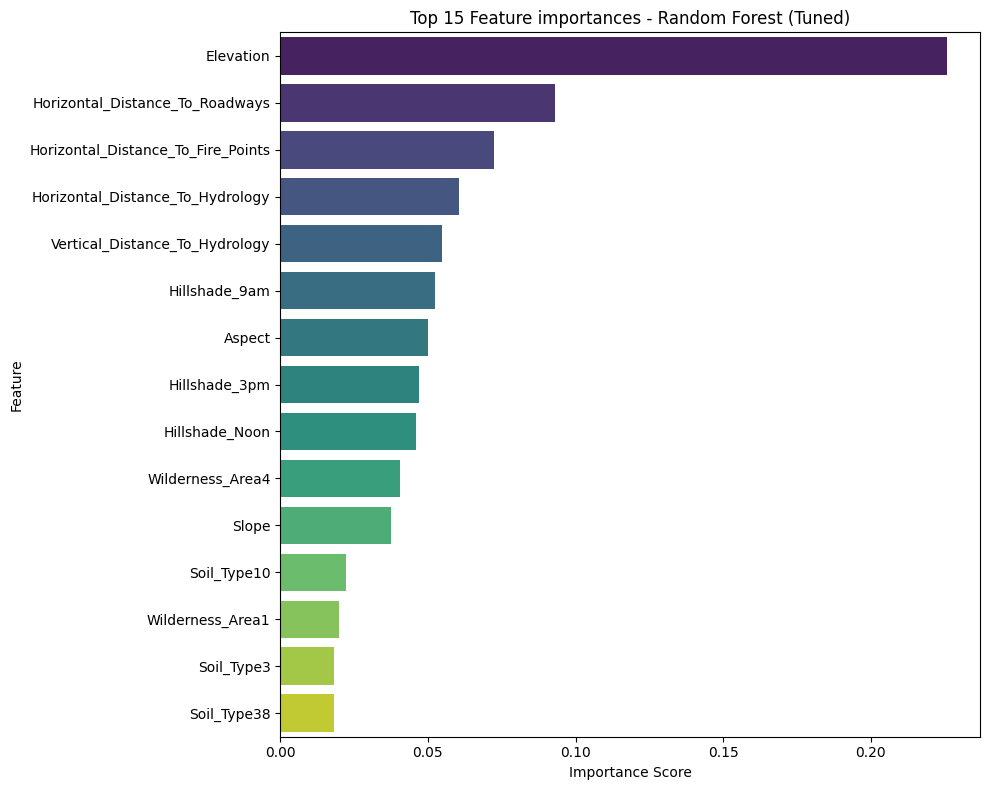

In [29]:
#Featuire Importance Plot

importances = rf_best.feature_importances_
feature_names = x.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature importances - Random Forest (Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



**Insight:**
**Elevation is by far the most important feature**, with an importance score of ~0.22 — more than double the next closest feature. This strongly confirms what we observed during EDA, where the boxplot of Elevation by Cover_Type showed clear separation between classes.

The next most important features are **Horizontal_Distance_To_Roadways (~0.09)**, **Horizontal_Distance_To_Fire_Points (~0.07)**, and **Horizontal_Distance_To_Hydrology (~0.06)** — all distance-based features, showing that how far a location is from human infrastructure (roads) and natural features (water, fire points) plays a meaningful role in determining forest cover type.

The three Hillshade features (9am, 3pm, Noon) and Aspect show moderate, fairly similar importance (~0.04–0.05 each), suggesting sunlight exposure and slope direction contribute some predictive value, though much less than Elevation.

Interestingly, **individual Soil_Type and Wilderness_Area columns rank quite low** in the top 15, despite there being 44 such binary columns in total. This suggests that while soil/wilderness information does help (some do appear in the top 15, like Wilderness_Area4 and Soil_Type10), no single soil type or wilderness area is a dominant predictor on its own — their combined effect across 44 columns likely still matters, but individually they are far less powerful than continuous features like Elevation.

**Overall takeaway:** This feature importance ranking directly validates our EDA process — the features we identified as showing strong separation across Cover Types (especially Elevation) turned out to be the most important ones for the actual trained model.

## Challenges Faced

**1. Row count mismatch with the original problem brief**
The project brief mentioned the full dataset has ~581,000 rows, but the actual `train.csv` provided only contained 15,120 rows. This was resolved by confirming the correct row count using `df.shape` and updating the Dataset Description accordingly, while noting that this smaller version is a standard training subset of the larger population.

**2. Perfectly balanced classes (unexpected)**
The project brief described the dataset as "heavily imbalanced," but EDA revealed the actual training data has exactly 2,160 rows per class — perfectly balanced. This meant class imbalance handling techniques (like SMOTE) were not needed for this subset, though it was noted as a possible limitation, since a model trained on balanced data may not generalize as well to the true imbalanced population.

**3. Cyclical nature of the Aspect feature**
Aspect is measured in degrees (0°–360°), where 0° and 360° represent the same direction. This circular nature was visible in its bimodal distribution during EDA. It was noted as a possible future improvement (e.g., sin/cos transformation) rather than applied directly, to keep the model comparison consistent across all 6 models.

**4. Deciding how to handle outliers across multiple models**
Several continuous features (e.g., Horizontal_Distance_To_Hydrology, Horizontal_Distance_To_Roadways) showed many outliers during boxplot analysis. Since the project required comparing multiple models with different sensitivities to outliers (tree-based models are robust, while KNN/SVM/Logistic Regression can be more sensitive), the decision was made to keep outliers for the initial comparison and let model performance itself reveal their impact, rather than removing them upfront.

**5. Overlapping feature ranges between certain Cover Types**
EDA and the final confusion matrix both showed that Cover Types 1 & 2, and Cover Types 3 & 6, have overlapping Elevation and Slope ranges. This made these class pairs consistently harder for every model to distinguish, and remained the biggest source of misclassification even after hyperparameter tuning.

**6. Long runtime for GridSearchCV on Gradient Boosting**
The initial Gradient Boosting parameter grid (18 combinations × 5 folds = 90 fits) took an impractically long time to run, since Gradient Boosting builds trees sequentially rather than in parallel. This was resolved by reducing the parameter grid to 8 combinations, which completed in a reasonable time while still meaningfully improving accuracy (78.88% → 84.88%).

## Techniques Used

| Technique | Purpose / Reason |
|-----------|-------------------|
| Histograms with KDE | To understand the distribution and skewness of each continuous feature |
| Boxplots (univariate) | To detect outliers in each continuous feature |
| Correlation Heatmap | To check for multicollinearity between continuous features before modeling |
| Boxplots grouped by Cover_Type | To visually compare how each feature varies across the 7 target classes |
| Groupby + median/describe | To get exact numerical values behind visual patterns, ensuring accurate written insights |
| Train-Test Split (70/30, stratified) | To evaluate model performance on unseen data while preserving class balance in both sets |
| StandardScaler | To standardize all features (mean ~0, std ~1), required for distance-based models like KNN, SVM, and Logistic Regression |
| Multiple Classification Models | Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, and SVM were trained and compared to find the best-performing algorithm |
| GridSearchCV (5-fold CV) | To tune hyperparameters of the top 2 models (Random Forest, Gradient Boosting) and find the best configuration |
| RandomizedSearchCV (considered) | Considered as a faster alternative to GridSearchCV when the full grid search took too long for Gradient Boosting |
| Classification Report (per-class metrics) | To evaluate precision, recall, and F1-score for each of the 7 classes individually, not just overall accuracy |
| Confusion Matrix (heatmap) | To visually identify which Cover Types were most frequently confused with each other |
| Feature Importance (Random Forest) | To identify which features contributed most to the model's predictions, validating findings from EDA |

## Conclusion

This project successfully built a multiclass classification model to predict forest cover type across 7 classes using 54 cartographic and ecological features from the Roosevelt National Forest dataset.

**Key findings:**
- The dataset (15,120 rows) was clean, with no missing values or duplicates, and was found to be perfectly balanced across all 7 classes (2,160 rows each) — differing from the imbalanced nature of the full 581,000-row population.
- **Elevation was the single most important predictor** (importance score ~0.22), more than double any other feature, followed by distance-based features (Horizontal_Distance_To_Roadways, Fire_Points, and Hydrology).
- Among 6 models compared, **ensemble tree-based models significantly outperformed linear and distance-based models**, confirming the presence of complex, non-linear relationships in the data.
- After hyperparameter tuning with GridSearchCV, **Random Forest (Tuned) achieved the best test accuracy of 85.63%**, with balanced precision and recall across all 7 classes (macro F1-score of 0.85).
- **Cover Types 1 & 2, and 3 & 6, were consistently the hardest to distinguish** across all models, due to genuinely overlapping Elevation and Slope ranges — this is a real-world pattern in the data rather than a model weakness.

**Final Recommendation:**
**Random Forest (Tuned)** with parameters `n_estimators=300, max_depth=30, min_samples_split=2, min_samples_leaf=1` is recommended for production deployment, offering the best combination of accuracy (85.63%), balanced per-class performance, and computational efficiency (faster training via parallel tree building compared to Gradient Boosting).

**Future Recommendations:**
1. Apply a sin/cos transformation to the Aspect feature to better capture its circular nature, which may slightly improve model performance.
2. Test outlier treatment (e.g., capping) specifically on outlier-sensitive models like KNN, SVM, and Logistic Regression, to see if it narrows the performance gap with tree-based models.
3. Since this training subset is perfectly balanced but the real-world population is not, validate the final model on a more realistically imbalanced sample if possible, to better estimate real-world production performance.
4. Investigate feature engineering specifically for the Cover Type 1 vs 2 and 3 vs 6 pairs (e.g., interaction features between Elevation and Slope) to try to reduce the persistent confusion between these classes.



**Model Deployment**

*1. Save model, scaler, & feature columns*

In [36]:
import joblib
import pickle

# save the tuned Random forest Model with compression

joblib.dump(rf_best, 'rf_model.pkl', compress=3)

# save the fitted scaler
with open('scaler.pkl', 'wb') as f:
 pickle.dump(scaler, f)

# save the exact column order so that the app must feel features in this exact order
feature_columns = list(x.columns)
with open('feature_columns.pkl', 'wb') as f:
  pickle.dump(feature_columns, f)

print("Saves : rf_model.pkl, scaler.pkl, feature_columns.pkl")


Saves : rf_model.pkl, scaler.pkl, feature_columns.pkl


*2. Create app.py*

In [37]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle


# Load model, scaler, and feature order
model = joblib.load('rf_model.pkl')

with open('scaler.pkl', 'rb') as f:
  scaler = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
  feature_columns = pickle.load(f)

st.set_page_config(page_title="Forest Cover Type Prediction", layout="centered")
st.title("🌳🌳 Forest Cover Type Prediction🌳🌳")
st.write("Enter the cartographic details below to predict the feature cover type")

# Continuous Features
st.subheader("Terrain & Distance Features")
elevation = st.number_input("Elevation (meter)", min_value=0, max_value=4000, value=2800)
aspect = st.number_input("Aspect (degrees, 0-360)", min_value=0, max_value=360, value=150)
slope = st.number_input("Slope (degrees)", min_value=0, max_value=90, value=15)
h_dist_hydro = st.number_input("Horizontal Distance To Hydrology (m)", min_value=0, value=1500)
v_dist_hydro = st.number_input("Vertical Distance To Hydrology (m)", value=30)
hdist_road = st.number_input("Horizontal Distance To Roadways (m)", min_value=0, value=1500)
hillshade_9am = st.slider("Hillshade at 9am (0-255)", 0, 255, 210)
hillshade_noon = st.slider("Hillshade at Noon (0-255)", 0, 255, 220)
hillshade_3pm = st.slider("Hillshade at 3pm (0-255)", 0, 255, 140)
h_dist_fire = st.number_input("Horizontal Distance To Fire Points (m)", min_value=0, value=1200)

# Wilderness Area (pick one, 1 of 4)
st.subheader("Wilderness Area")
wilderness = st.selectbox("Select Wilderness Area", [1,2,3,4])

# Soil Type (pick one , 1 of 40)
st.subheader("Soil Type")
soil_type = st.selectbox("Select Soil Type", list(range(1,41)))

# Build input row matching training feature order
if st.button("Predict Cover Type"):
  input_dict = dict.fromkeys(feature_columns,0)

  input_dict['Elevation'] = elevation
  input_dict['Aspect'] = aspect
  input_dict['Slope'] = slope
  input_dict['Horizontal_Distance_To_Hydrology'] = h_dist_hydro
  input_dict['Vertical_Distance_To_Hydrology'] = v_dist_hydro
  input_dict['Horizontal_Distance_To_Roadways'] = hdist_road
  input_dict['Hillshade_9am'] = hillshade_9am
  input_dict['Hillshade_Noon'] = hillshade_noon
  input_dict['Hillshade_3pm'] = hillshade_3pm
  input_dict['Horizontal_Distance_To_Fire_Points'] = h_dist_fire
  input_dict[f'Wilderness_Area{wilderness}'] = 1
  input_dict[f'Soil_Type{soil_type}'] = 1

  input_df = pd.DataFrame([input_dict])[feature_columns] #enforce correct column order
  input_scaled = scaler.transform(input_df)

  prediction = model.predict(input_scaled)[0]
  cover_type_names ={
      1: 'Spruce/Fir',
      2: 'Lodgepole Pine',
      3: 'Ponderosa Pine',
      4: 'Cottonwood/Willow',
      5: 'Aspen',
      6: 'Douglas-fir',
      7: 'Krummholz'
  }

  st.success(f"Predicted Cover Type: **{prediction} - {cover_type_names[prediction]}**")

Writing app.py


*3. Create requirements.txt*

In [38]:

%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib


Writing requirements.txt
